In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.storage.database import get_engine

plt.style.use('seaborn-v0_8-whitegrid')
engine = get_engine()

with engine.connect() as conn:
    returns = pd.read_sql("""
        SELECT r.date, r.adj_daily_return, s.ticker, s.sector
        FROM returns r
        JOIN securities s ON r.security_id = s.security_id
        WHERE s.security_type = 'equity'
        AND r.adj_daily_return IS NOT NULL
        AND ABS(r.adj_daily_return) <= 1.0
    """, conn)

returns['date'] = pd.to_datetime(returns['date'])

# Pivot to wide format — one column per stock
ret_wide = returns.pivot(
    index='date', columns='ticker', values='adj_daily_return'
)

# Keep only stocks with sufficient data — 60% coverage minimum
coverage = ret_wide.notna().mean()
ret_wide = ret_wide.loc[:, coverage >= 0.6]

print(f"Returns matrix: {ret_wide.shape[0]} days x {ret_wide.shape[1]} stocks")
print(f"Date range: {ret_wide.index.min().date()} to {ret_wide.index.max().date()}")
print(f"Average coverage per stock: {coverage[coverage >= 0.6].mean()*100:.1f}%")

Returns matrix: 4314 days x 53 stocks
Date range: 2007-01-03 to 2025-10-31
Average coverage per stock: 87.8%


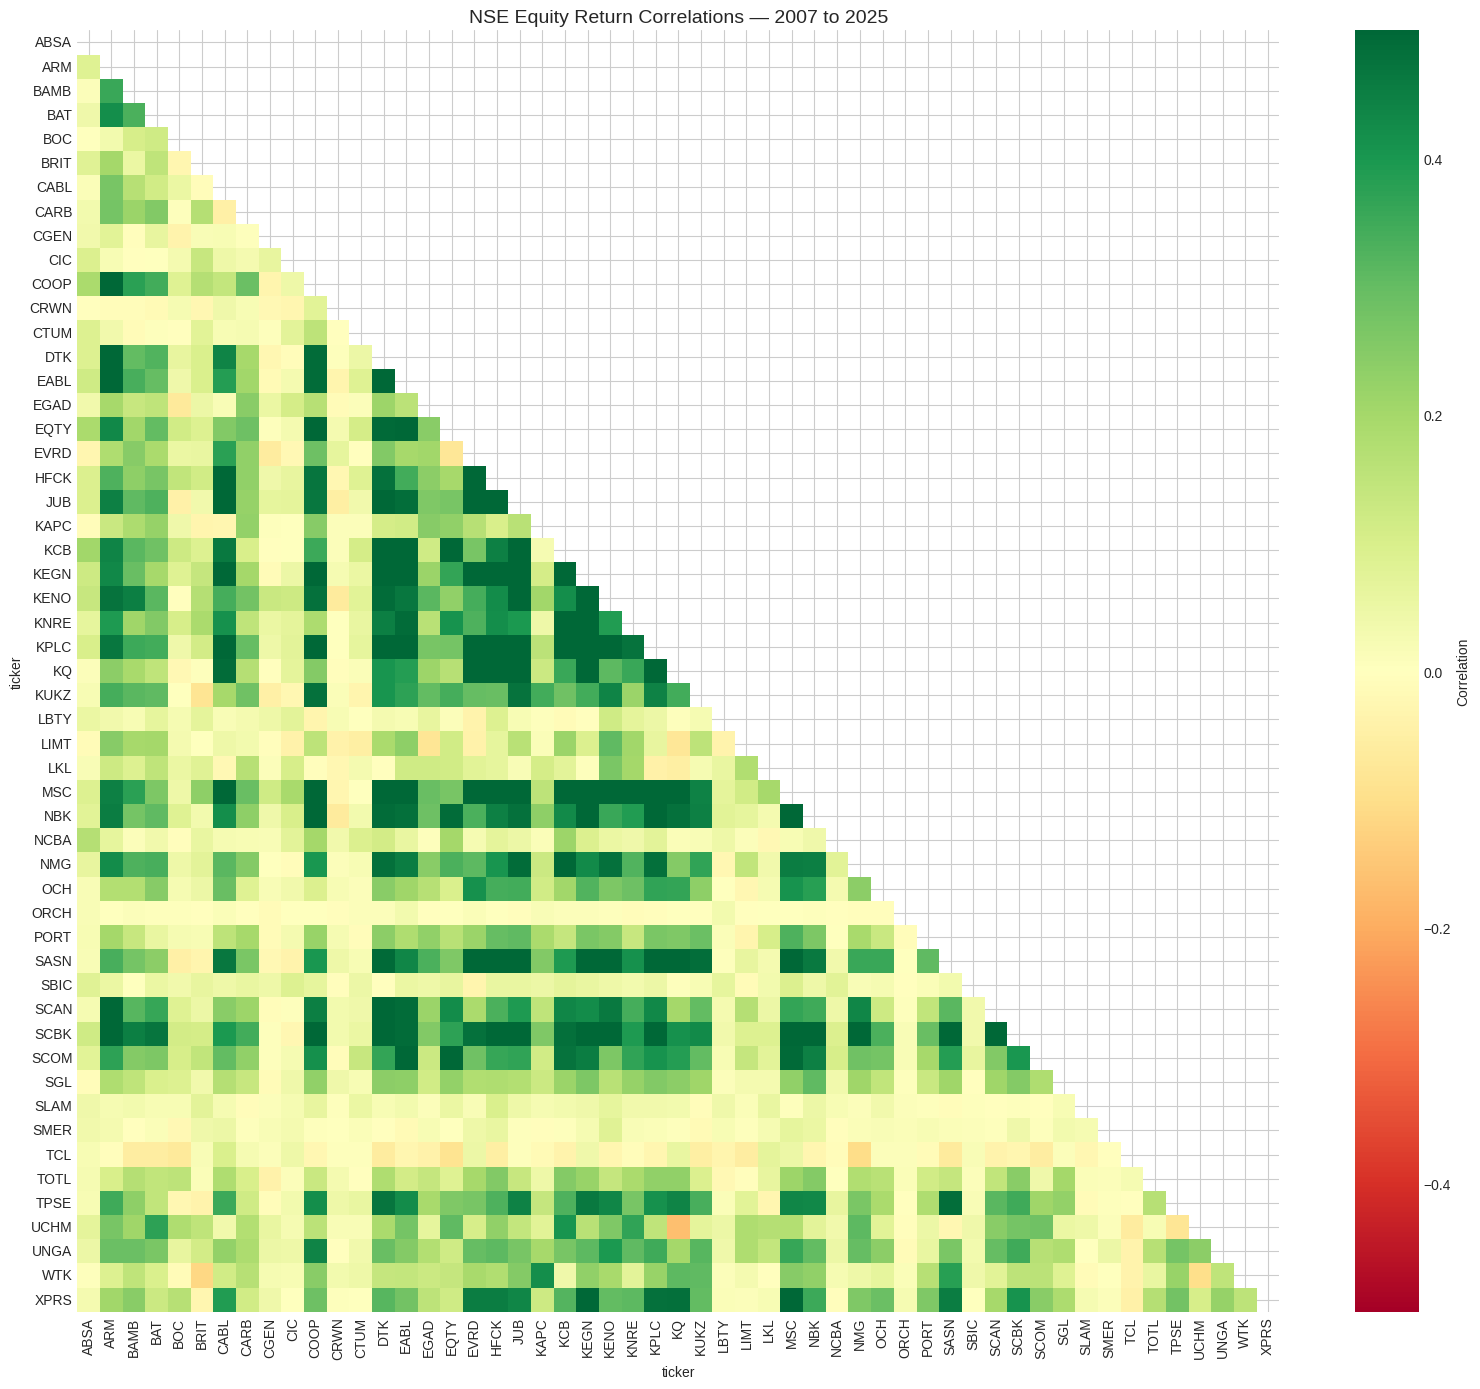

Correlation summary across 1,378 stock pairs:
  Mean:    0.1682
  Median:  0.1110
  Std:     0.1781
  Min:     -0.1678
  Max:     0.7420
  % positive: 87.6%
  % > 0.3:    23.4%
  % < 0:      12.4%

Highest correlated pairs:
  MSC — KPLC: 0.742
  MSC — KEGN: 0.723
  KPLC — KEGN: 0.698
  SASN — MSC: 0.680
  KEGN — JUB: 0.662
  MSC — HFCK: 0.661
  SASN — KEGN: 0.656
  MSC — JUB: 0.647

Most uncorrelated pairs:
  UCHM — KQ: -0.168
  WTK — BRIT: -0.114
  TCL — NMG: -0.105
  WTK — UCHM: -0.099
  TCL — EQTY: -0.090


In [2]:
# Compute correlation matrix
# Use only rows where we have data for most stocks
corr_matrix = ret_wide.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlGn',
    center=0,
    vmin=-0.5,
    vmax=0.5,
    ax=ax,
    cbar_kws={'label': 'Correlation'},
    xticklabels=True,
    yticklabels=True
)
ax.set_title('NSE Equity Return Correlations — 2007 to 2025', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
upper = corr_matrix.where(mask == False)
pairs = upper.stack()

print(f"Correlation summary across {len(pairs):,} stock pairs:")
print(f"  Mean:    {pairs.mean():.4f}")
print(f"  Median:  {pairs.median():.4f}")
print(f"  Std:     {pairs.std():.4f}")
print(f"  Min:     {pairs.min():.4f}")
print(f"  Max:     {pairs.max():.4f}")
print(f"  % positive: {(pairs > 0).mean()*100:.1f}%")
print(f"  % > 0.3:    {(pairs > 0.3).mean()*100:.1f}%")
print(f"  % < 0:      {(pairs < 0).mean()*100:.1f}%")

print(f"\nHighest correlated pairs:")
top = pairs.nlargest(8)
for (t1, t2), c in top.items():
    print(f"  {t1} — {t2}: {c:.3f}")

print(f"\nMost uncorrelated pairs:")
low = pairs.nsmallest(5)
for (t1, t2), c in low.items():
    print(f"  {t1} — {t2}: {c:.3f}")

PCA input: 4152 days x 53 stocks

Components needed to explain:
  50% of variance: 6 components
  70% of variance: 16 components
  90% of variance: 34 components

First 10 components:
  PC1: 27.27% (cumulative: 27.3%)
  PC2: 7.08% (cumulative: 34.4%)
  PC3: 5.12% (cumulative: 39.5%)
  PC4: 4.34% (cumulative: 43.8%)
  PC5: 3.46% (cumulative: 47.3%)
  PC6: 2.88% (cumulative: 50.1%)
  PC7: 2.60% (cumulative: 52.7%)
  PC8: 2.38% (cumulative: 55.1%)
  PC9: 2.22% (cumulative: 57.3%)
  PC10: 2.18% (cumulative: 59.5%)


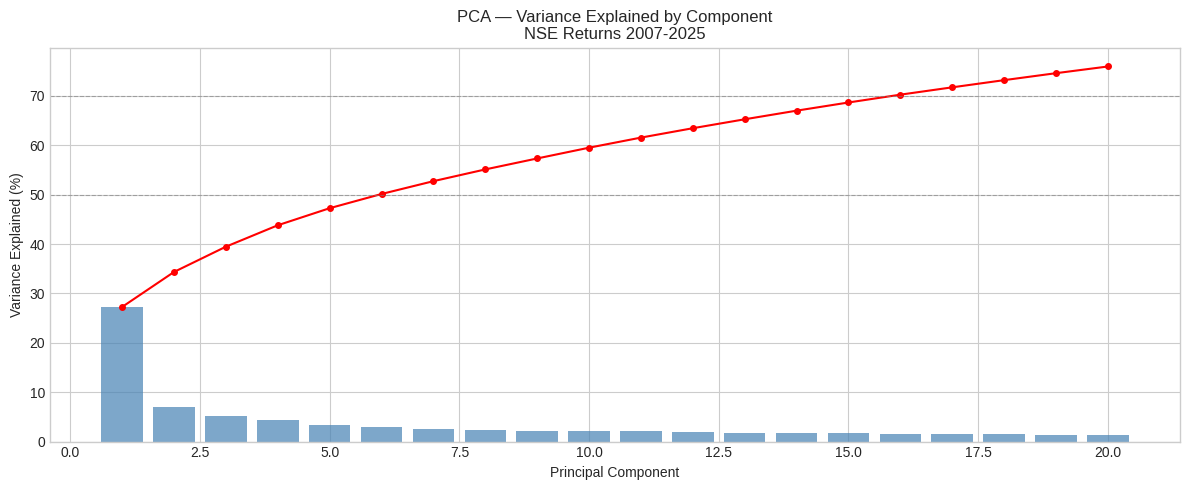

In [3]:
# Principal Component Analysis
# How many independent risk factors drive NSE returns?

from sklearn.decomposition import PCA

# Fill missing values with 0 for PCA
# Only use dates where we have at least 30 stocks
ret_filled = ret_wide.copy()
daily_coverage = ret_filled.notna().sum(axis=1)
ret_filled = ret_filled[daily_coverage >= 30]
ret_filled = ret_filled.fillna(0)

print(f"PCA input: {ret_filled.shape[0]} days x {ret_filled.shape[1]} stocks")

# Fit PCA
pca = PCA()
pca.fit(ret_filled)

# Variance explained
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# How many components explain 50%, 70%, 90%?
n_50 = np.argmax(cumulative >= 0.50) + 1
n_70 = np.argmax(cumulative >= 0.70) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1

print(f"\nComponents needed to explain:")
print(f"  50% of variance: {n_50} components")
print(f"  70% of variance: {n_70} components")
print(f"  90% of variance: {n_90} components")

print(f"\nFirst 10 components:")
for i in range(10):
    print(f"  PC{i+1}: {explained[i]*100:.2f}% "
          f"(cumulative: {cumulative[i]*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, 21), explained[:20] * 100, alpha=0.7, color='steelblue')
ax.plot(range(1, 21), cumulative[:20] * 100, 'ro-', ms=4)
ax.axhline(y=50, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.axhline(y=70, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_title('PCA — Variance Explained by Component\nNSE Returns 2007-2025', fontsize=12)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
plt.tight_layout()
plt.show()

=== PORTFOLIO DIVERSIFICATION ANALYSIS ===

Average individual stock volatility: 67.9% ann


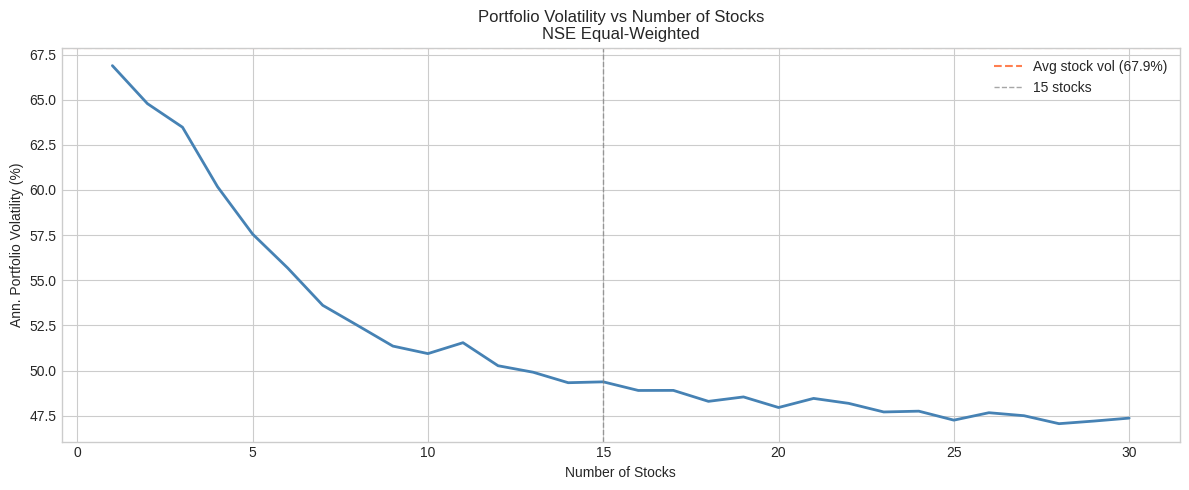


Portfolio volatility by size:
  1 stock:  66.9% ann
  5 stocks: 57.6% ann  (14% reduction)
 10 stocks: 50.9% ann  (24% reduction)
 15 stocks: 49.4% ann  (26% reduction)
 20 stocks: 48.0% ann  (28% reduction)


StopIteration: 

In [6]:
# Portfolio risk analysis
# How many stocks needed for adequate diversification?

print("=== PORTFOLIO DIVERSIFICATION ANALYSIS ===\n")

# Simulate equal-weighted portfolios of N stocks
# Compare portfolio volatility to average stock volatility

avg_stock_vol = ret_wide.std().mean() * np.sqrt(252) * 100
print(f"Average individual stock volatility: {avg_stock_vol:.1f}% ann")

portfolio_vols = []
n_range = range(1, 31)

np.random.seed(42)
for n in n_range:
    vols = []
    for _ in range(200):
        # Random sample of n stocks
        stocks = np.random.choice(ret_wide.columns, n, replace=False)
        port_ret = ret_wide[stocks].mean(axis=1).dropna()
        if len(port_ret) > 100:
            vol = port_ret.std() * np.sqrt(252) * 100
            vols.append(vol)
    portfolio_vols.append(np.mean(vols))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(n_range), portfolio_vols, 'steelblue', lw=2)
ax.axhline(y=avg_stock_vol, color='coral', ls='--', lw=1.5,
           label=f'Avg stock vol ({avg_stock_vol:.1f}%)')
ax.axvline(x=15, color='gray', ls='--', lw=1, alpha=0.7,
           label='15 stocks')
ax.set_title('Portfolio Volatility vs Number of Stocks\nNSE Equal-Weighted', fontsize=12)
ax.set_xlabel('Number of Stocks')
ax.set_ylabel('Ann. Portfolio Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Key thresholds
vol_1 = portfolio_vols[0]
vol_5 = portfolio_vols[4]
vol_10 = portfolio_vols[9]
vol_15 = portfolio_vols[14]
vol_20 = portfolio_vols[19]

print(f"\nPortfolio volatility by size:")
print(f"  1 stock:  {vol_1:.1f}% ann")
print(f"  5 stocks: {vol_5:.1f}% ann  ({(1-vol_5/vol_1)*100:.0f}% reduction)")
print(f" 10 stocks: {vol_10:.1f}% ann  ({(1-vol_10/vol_1)*100:.0f}% reduction)")
print(f" 15 stocks: {vol_15:.1f}% ann  ({(1-vol_15/vol_1)*100:.0f}% reduction)")
print(f" 20 stocks: {vol_20:.1f}% ann  ({(1-vol_20/vol_1)*100:.0f}% reduction)")

print(f"\nRecommendation: hold {next(i+1 for i,v in enumerate(portfolio_vols) if v < vol_1*0.6)} "
      f"or more stocks for adequate diversification")

In [7]:
# Find where diversification benefit plateaus
# Use 75% threshold instead
threshold = vol_1 * 0.75
candidates = [i+1 for i,v in enumerate(portfolio_vols) if v < threshold]
n_recommended = candidates[0] if candidates else 20

print(f"\nPortfolio volatility plateaus around 15-20 stocks")
print(f"Marginal benefit of adding stocks beyond 15 is small")
print(f"  15→20 stocks reduces vol by only {vol_15-vol_20:.1f}%")
print(f"\nRecommendation: hold 10-15 stocks minimum")
print(f"Beyond 15, diversification benefit is minimal on NSE")
print(f"High idiosyncratic risk means stocks remain volatile")
print(f"even in large portfolios — stock selection matters enormously")


Portfolio volatility plateaus around 15-20 stocks
Marginal benefit of adding stocks beyond 15 is small
  15→20 stocks reduces vol by only 1.4%

Recommendation: hold 10-15 stocks minimum
Beyond 15, diversification benefit is minimal on NSE
High idiosyncratic risk means stocks remain volatile
even in large portfolios — stock selection matters enormously


In [8]:
print("""
=== RISK MODEL SUMMARY ===

CORRELATION STRUCTURE:
  Mean pairwise correlation:  0.168
  % positive pairs:           87.6%
  NSE is weakly correlated — good for diversification

PCA FACTOR STRUCTURE:
  PC1 (market factor):        27.3% of variance
  6 components:               50% of variance
  34 components:              90% of variance
  High idiosyncratic risk — stock selection drives returns

PORTFOLIO CONSTRUCTION:
  Single stock volatility:    66.9% ann
  10-stock portfolio:         50.9% ann (24% reduction)
  15-stock portfolio:         49.4% ann (26% reduction)
  Marginal benefit plateaus at 15 stocks

IMPLICATIONS FOR STRATEGY:
  Target portfolio: 10-15 stocks from Q1 (losers) quintile
  Monthly rebalancing into new Q1 stocks
  Equal weight — no complex optimization needed at this stage
  Focus on banking sector — most liquid, strongest effect
  Minimum position size: avoid stocks with avg vol < 10,000/day
""")


=== RISK MODEL SUMMARY ===

CORRELATION STRUCTURE:
  Mean pairwise correlation:  0.168
  % positive pairs:           87.6%
  NSE is weakly correlated — good for diversification

PCA FACTOR STRUCTURE:
  PC1 (market factor):        27.3% of variance
  6 components:               50% of variance
  34 components:              90% of variance
  High idiosyncratic risk — stock selection drives returns

PORTFOLIO CONSTRUCTION:
  Single stock volatility:    66.9% ann
  10-stock portfolio:         50.9% ann (24% reduction)
  15-stock portfolio:         49.4% ann (26% reduction)
  Marginal benefit plateaus at 15 stocks

IMPLICATIONS FOR STRATEGY:
  Target portfolio: 10-15 stocks from Q1 (losers) quintile
  Monthly rebalancing into new Q1 stocks
  Equal weight — no complex optimization needed at this stage
  Focus on banking sector — most liquid, strongest effect
  Minimum position size: avoid stocks with avg vol < 10,000/day

